# DPL Confidence Models — Evaluation

Loads the three pre-trained CPU models that produce **calibrated probability
scores** and re-runs all evaluation sections from `dpl_main_confidence.ipynb`.

| Model | Saved in | How confidence is produced |
|---|---|---|
| TF-IDF + Calibrated SVC | `models/cal_svc/` | `CalibratedClassifierCV` (Platt sigmoid) |
| TF-IDF + Logistic Regression | `models/lr/` | Native `predict_proba()` |
| DistilBERT | `models/distilbert_conf/` | Softmax over logits |

## Structure
1. Load test data  
2. Load saved models  
3. Model A — Calibrated SVC evaluation  
4. Model B — Logistic Regression evaluation  
5. Model C — DistilBERT evaluation  
6. Calibration quality — reliability diagrams  
7. Confidence threshold analysis  
8. Inference helper — top-K with confidence  


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
)
from sklearn.calibration import calibration_curve
from transformers import pipeline as hf_pipeline


## 1. Load Test Data

In [3]:
DATASETS_DIR = "../datasets"

test_df = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")

# Rebuild label encoder from the saved label_classes.json of any one model
_LABEL_PATH = "../models/cal_svc/label_classes.json"
if not os.path.isfile(_LABEL_PATH):
    raise FileNotFoundError(
        f"Label classes not found at '{_LABEL_PATH}'. "
        "Run dpl_main_confidence.ipynb first."
    )
with open(_LABEL_PATH) as f:
    _lmap = json.load(f)

id2label = {int(k): v for k, v in _lmap["id2label"].items()}
label2id = _lmap["label2id"]

le = LabelEncoder()
le.classes_ = np.array(sorted(label2id.keys()))

X_test = test_df["description"].tolist()
y_test = le.transform(test_df["dpl_tag"])

print(f"Test rows : {len(test_df):,}  |  Classes : {len(le.classes_)}")


Test rows : 2,272  |  Classes : 76


## 2. Load Saved Models

In [4]:
_REQUIRED = {
    "cal_svc":  "../models/cal_svc/model.joblib",
    "lr":       "../models/lr/model.joblib",
    "distilbert_conf_model": "../models/distilbert_conf/model",
}

for name, path in _REQUIRED.items():
    exists = os.path.isfile(path) if not path.endswith("/model") else os.path.isdir(path)
    if not exists:
        raise FileNotFoundError(
            f"Required artefact '{name}' not found at '{path}'. "
            "Run dpl_main_confidence.ipynb first."
        )

svc_pipeline = joblib.load("../models/cal_svc/model.joblib")
lr_pipeline  = joblib.load("../models/lr/model.joblib")

print("sklearn pipelines loaded.")
print(f"  Calibrated SVC pipeline steps : {[s[0] for s in svc_pipeline.steps]}")
print(f"  Logistic Regression steps     : {[s[0] for s in lr_pipeline.steps]}")


sklearn pipelines loaded.
  Calibrated SVC pipeline steps : ['features', 'clf']
  Logistic Regression steps     : ['features', 'clf']


## 3. Model A — TF-IDF + Calibrated SVC

`CalibratedClassifierCV` wraps `LinearSVC` with Platt (sigmoid) calibration
to produce probability estimates.


In [5]:
svc_preds = svc_pipeline.predict(X_test)
svc_probs = svc_pipeline.predict_proba(X_test)   # (n, 76)
svc_conf  = svc_probs.max(axis=1)

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1  = f1_score(y_test, svc_preds, average="weighted", zero_division=0)

print(f"Accuracy          : {svc_acc:.4f}")
print(f"Weighted F1       : {svc_f1:.4f}")
print(f"Mean confidence   : {svc_conf.mean():.4f}")
print(f"Median confidence : {np.median(svc_conf):.4f}")
print(f"Low-conf (<0.5)   : {(svc_conf < 0.5).sum()} samples ({100*(svc_conf<0.5).mean():.1f}%)")
print(f"Low-conf (<0.8)   : {(svc_conf < 0.8).sum()} samples ({100*(svc_conf<0.8).mean():.1f}%)")


Accuracy          : 0.9996
Weighted F1       : 0.9996
Mean confidence   : 0.9777
Median confidence : 0.9797
Low-conf (<0.5)   : 0 samples (0.0%)
Low-conf (<0.8)   : 13 samples (0.6%)


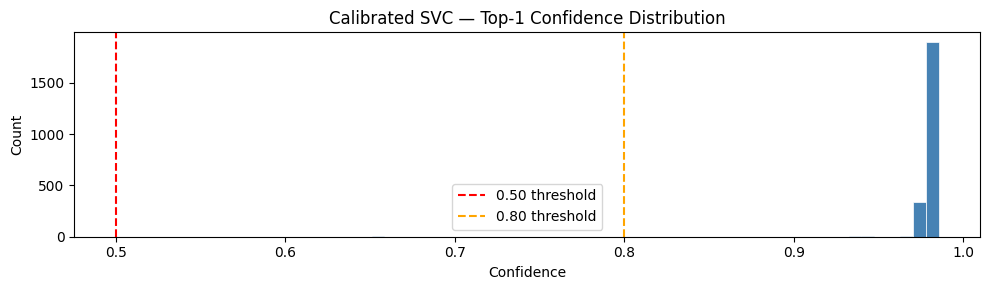

In [6]:
# Confidence distribution — Calibrated SVC
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(svc_conf, bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(0.50, color="red",    linestyle="--", label="0.50 threshold")
ax.axvline(0.80, color="orange", linestyle="--", label="0.80 threshold")
ax.set_title("Calibrated SVC — Top-1 Confidence Distribution")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Model B — TF-IDF + Logistic Regression

In [7]:
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)
lr_conf  = lr_probs.max(axis=1)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted", zero_division=0)

print(f"Accuracy          : {lr_acc:.4f}")
print(f"Weighted F1       : {lr_f1:.4f}")
print(f"Mean confidence   : {lr_conf.mean():.4f}")
print(f"Median confidence : {np.median(lr_conf):.4f}")
print(f"Low-conf (<0.5)   : {(lr_conf < 0.5).sum()} samples ({100*(lr_conf<0.5).mean():.1f}%)")
print(f"Low-conf (<0.8)   : {(lr_conf < 0.8).sum()} samples ({100*(lr_conf<0.8).mean():.1f}%)")


Accuracy          : 0.9996
Weighted F1       : 0.9996
Mean confidence   : 0.9599
Median confidence : 0.9727
Low-conf (<0.5)   : 1 samples (0.0%)
Low-conf (<0.8)   : 23 samples (1.0%)


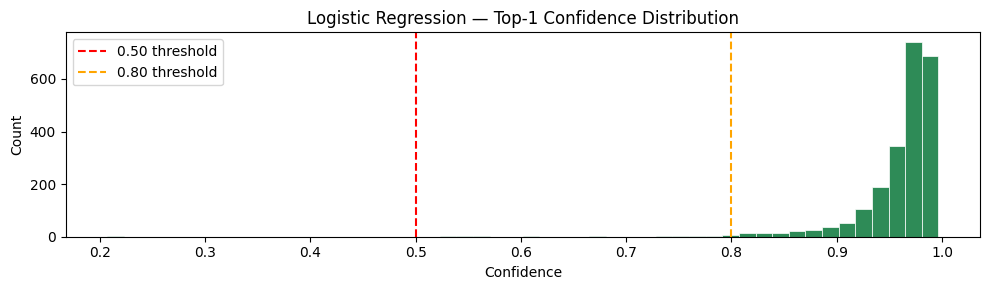

In [8]:
# Confidence distribution — Logistic Regression
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(lr_conf, bins=50, color="seagreen", edgecolor="white", linewidth=0.5)
ax.axvline(0.50, color="red",    linestyle="--", label="0.50 threshold")
ax.axvline(0.80, color="orange", linestyle="--", label="0.80 threshold")
ax.set_title("Logistic Regression — Top-1 Confidence Distribution")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Model C — DistilBERT

In [9]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

DB_MODEL_DIR = "../models/distilbert_conf/model"

tokenizer_db = AutoTokenizer.from_pretrained(DB_MODEL_DIR)

def tokenize(batch):
    return tokenizer_db(batch["text"], truncation=True, padding="max_length", max_length=64)

test_ds = Dataset.from_dict({"text": X_test, "labels": y_test.tolist()})
test_ds = test_ds.map(tokenize, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

db_model = AutoModelForSequenceClassification.from_pretrained(
    DB_MODEL_DIR,
    num_labels=len(le.classes_),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

eval_args = TrainingArguments(
    output_dir="../models/distilbert_conf/eval_tmp",
    per_device_eval_batch_size=64,
    fp16=False, bf16=False,
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }

db_trainer = Trainer(
    model=db_model,
    args=eval_args,
    processing_class=tokenizer_db,
    compute_metrics=compute_metrics,
)

db_results = db_trainer.predict(test_ds)
db_preds = np.argmax(db_results.predictions, axis=-1)
db_probs = __import__("torch").nn.functional.softmax(
    __import__("torch").tensor(db_results.predictions), dim=-1
).numpy()
db_conf  = db_probs.max(axis=1)

db_acc = accuracy_score(y_test, db_preds)
db_f1  = f1_score(y_test, db_preds, average="weighted", zero_division=0)

print(f"Accuracy          : {db_acc:.4f}")
print(f"Weighted F1       : {db_f1:.4f}")
print(f"Mean confidence   : {db_conf.mean():.4f}")
print(f"Median confidence : {np.median(db_conf):.4f}")
print(f"Low-conf (<0.5)   : {(db_conf < 0.5).sum()} samples ({100*(db_conf<0.5).mean():.1f}%)")
print(f"Low-conf (<0.8)   : {(db_conf < 0.8).sum()} samples ({100*(db_conf<0.8).mean():.1f}%)")


Map:   0%|          | 0/2272 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy          : 0.9991
Weighted F1       : 0.9991
Mean confidence   : 0.9010
Median confidence : 0.9074
Low-conf (<0.5)   : 5 samples (0.2%)
Low-conf (<0.8)   : 41 samples (1.8%)


## Comparison Summary

In [13]:
comparison = {
    "Calibrated SVC":      {"Accuracy": svc_acc, "Weighted F1": svc_f1,
                             "Mean conf": svc_conf.mean(), "Low-conf <0.5": (svc_conf < 0.5).mean()},
    "Logistic Regression": {"Accuracy": lr_acc,  "Weighted F1": lr_f1,
                             "Mean conf": lr_conf.mean(),  "Low-conf <0.5": (lr_conf  < 0.5).mean()},
    "DistilBERT":          {"Accuracy": db_acc,  "Weighted F1": db_f1,
                             "Mean conf": db_conf.mean(),  "Low-conf <0.5": (db_conf  < 0.5).mean()},
}
df_cmp = pd.DataFrame(comparison).T
df_cmp = df_cmp.map(lambda x: f"{x:.4f}")
print(df_cmp.to_string())


                    Accuracy Weighted F1 Mean conf Low-conf <0.5
Calibrated SVC        0.9996      0.9996    0.9777        0.0000
Logistic Regression   0.9996      0.9996    0.9599        0.0004
DistilBERT            0.9991      0.9991    0.9010        0.0022


## 6. Calibration Quality — Reliability Diagrams

A well-calibrated model's curve should follow the diagonal. Points **above** the
diagonal mean the model is under-confident; points **below** mean over-confident.


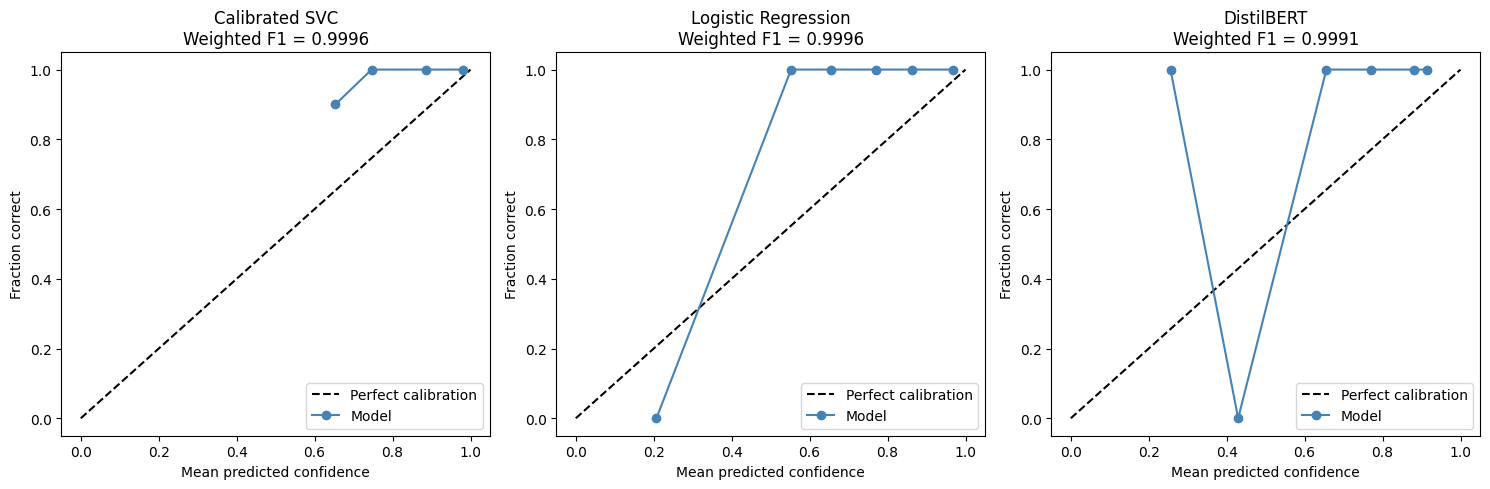

In [14]:
models_conf = [
    ("Calibrated SVC",      svc_preds, svc_probs, svc_f1),
    ("Logistic Regression", lr_preds,  lr_probs,  lr_f1),
    ("DistilBERT",          db_preds,  db_probs,  db_f1),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, preds, probs, f1) in zip(axes, models_conf):
    # Binary: correct prediction vs not
    y_true_binary = (preds == y_test).astype(int)
    max_probs     = probs.max(axis=1)
    fraction_pos, mean_pred = calibration_curve(y_true_binary, max_probs, n_bins=10)

    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_pred, fraction_pos, "o-", color="steelblue", label="Model")
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Fraction correct")
    ax.set_title(f"{name}\nWeighted F1 = {f1:.4f}")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


## 7. Confidence Threshold Analysis

Accepting only predictions above a threshold improves accuracy on the **accepted**
subset — at the cost of more **abstentions** (deferred to human review).


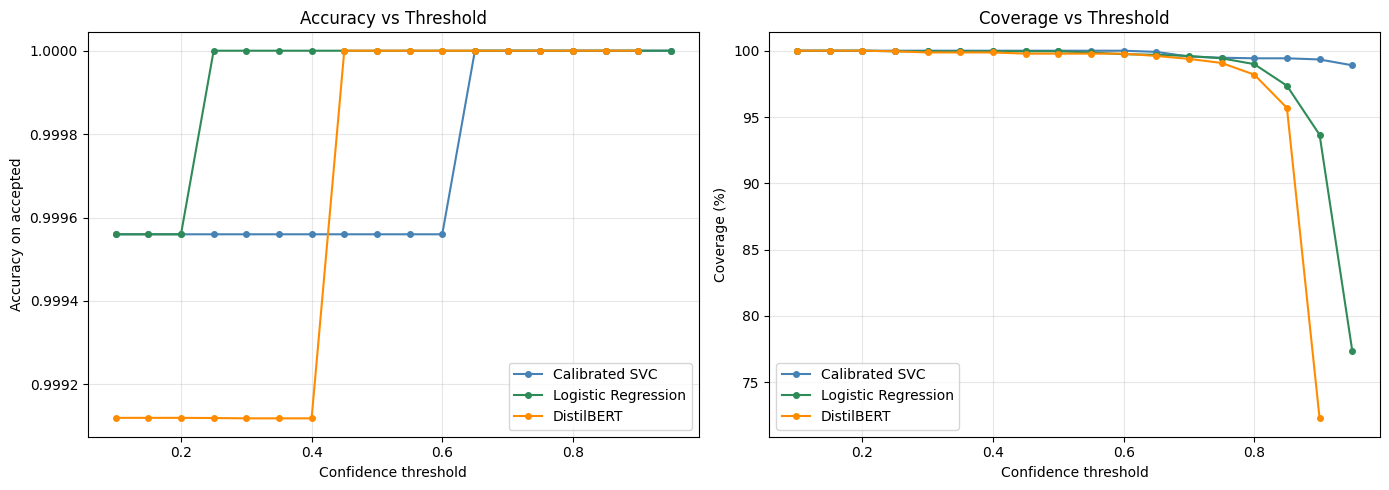


Model                  Thresh   Coverage  Acc (accepted)
----------------------------------------------------------
Calibrated SVC           0.50     100.0%          0.9996
Calibrated SVC           0.80      99.4%          1.0000
Calibrated SVC           0.90      99.3%          1.0000
Logistic Regression      0.50     100.0%          1.0000
Logistic Regression      0.80      99.0%          1.0000
Logistic Regression      0.90      93.7%          1.0000
DistilBERT               0.50      99.8%          1.0000
DistilBERT               0.80      98.2%          1.0000
DistilBERT               0.90      72.3%          1.0000


In [15]:
def threshold_analysis(preds, conf, y_true, label):
    thresholds = np.arange(0.1, 1.0, 0.05)
    rows = []
    for t in thresholds:
        mask = conf >= t
        if mask.sum() == 0:
            continue
        accepted_acc = accuracy_score(y_true[mask], preds[mask])
        coverage     = mask.mean()
        rows.append({"threshold": t, "coverage": coverage,
                     "accuracy_on_accepted": accepted_acc, "label": label})
    return pd.DataFrame(rows)

svc_thresh = threshold_analysis(svc_preds, svc_conf, y_test, "Calibrated SVC")
lr_thresh  = threshold_analysis(lr_preds,  lr_conf,  y_test, "Logistic Regression")
db_thresh  = threshold_analysis(db_preds,  db_conf,  y_test, "DistilBERT")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue", "seagreen", "darkorange"]

for df, color in zip([svc_thresh, lr_thresh, db_thresh], colors):
    name = df["label"].iloc[0]
    ax1.plot(df["threshold"], df["accuracy_on_accepted"], "-o", color=color,
             markersize=4, label=name)
    ax2.plot(df["threshold"], df["coverage"] * 100, "-o", color=color,
             markersize=4, label=name)

ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Accuracy on accepted")
ax1.set_title("Accuracy vs Threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Confidence threshold")
ax2.set_ylabel("Coverage (%)")
ax2.set_title("Coverage vs Threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary at key thresholds
print(f"\n{'Model':<22} {'Thresh':>6}  {'Coverage':>9}  {'Acc (accepted)':>14}")
print("-" * 58)
for df in [svc_thresh, lr_thresh, db_thresh]:
    name = df["label"].iloc[0]
    for thr in [0.5, 0.8, 0.9]:
        row = df[df["threshold"] >= thr].iloc[0] if len(df[df["threshold"] >= thr]) else None
        if row is not None:
            print(f"{name:<22} {thr:>6.2f}  {row['coverage']:>9.1%}  {row['accuracy_on_accepted']:>14.4f}")


## 8. Inference Helper — Top-K with Confidence

In [16]:
def predict_with_confidence(descriptions: list[str],
                            model_path: str = "../models/cal_svc/model.joblib",
                            top_k: int = 3,
                            threshold: float = 0.0) -> list[dict]:
    """
    Predict DPL tag(s) for free-text descriptions with calibrated confidence.

    Returns a list of dicts, one per description:
      {
        'description': str,
        'top_prediction': {'tag': str, 'confidence': float},
        'top_k': [{'tag': str, 'confidence': float}, ...],
        'accepted': bool   # True if confidence >= threshold
      }
    """
    label_path = model_path.replace("model.joblib", "label_classes.json")
    with open(label_path) as f:
        lmap = json.load(f)
    pipe = joblib.load(model_path)

    probs = pipe.predict_proba(descriptions)   # (n, num_classes)
    results = []
    for i, desc in enumerate(descriptions):
        row      = probs[i]
        top_idxs = np.argsort(row)[::-1][:top_k]
        top_list = [{"tag": lmap["id2label"][str(j)],
                     "confidence": round(float(row[j]), 4)} for j in top_idxs]
        results.append({
            "description":    desc,
            "top_prediction": top_list[0],
            "top_k":          top_list,
            "accepted":       top_list[0]["confidence"] >= threshold,
        })
    return results


test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Interest received on shareholder loan – April 2025",
    "Google Ads campaign – Q2 2026",
    "Office rent – London HQ – April 2026",
    "Redundancy costs – IT department – 2025",
    "AWS cloud hosting – February subscription",
    "FX loss on USD settlement – AP-78341",
    "Miscellaneous expense",    # intentionally ambiguous
]


In [17]:
# Calibrated SVC predictions
print("=== Calibrated SVC — Top-3 with confidence ===")
results = predict_with_confidence(test_descs, "../models/cal_svc/model.joblib",
                                   top_k=3, threshold=0.5)
print(f"\n{'Description':<50} {'Tag':<8} {'Conf':>6}  {'#2':<8} {'#3':<8}  Status")
print("-" * 100)
for r in results:
    t1 = r["top_k"][0]
    t2 = r["top_k"][1] if len(r["top_k"]) > 1 else {"tag": "-", "confidence": 0}
    t3 = r["top_k"][2] if len(r["top_k"]) > 2 else {"tag": "-", "confidence": 0}
    status = "\u2713" if r["accepted"] else "\u26a0 LOW"
    print(f"{r['description'][:49]:<50} {t1['tag']:<8} {t1['confidence']:>6.3f}  "
          f"{t2['tag']:<8} {t3['tag']:<8}  {status}")


=== Calibrated SVC — Top-3 with confidence ===

Description                                        Tag        Conf  #2       #3        Status
----------------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003    0.978  DPL040   DPL051    ✓
Monthly payroll – March 2026 – Finance             DPL068    0.976  DPL058   DPL057    ✓
Interest charged on HSBC overdraft – January       DPL035    0.980  DPL076   DPL050    ✓
Interest received on shareholder loan – April 202  DPL075    0.983  DPL076   DPL072    ✓
Google Ads campaign – Q2 2026                      DPL001    0.979  DPL028   DPL029    ✓
Office rent – London HQ – April 2026               DPL055    0.979  DPL029   DPL022    ✓
Redundancy costs – IT department – 2025            DPL059    0.983  DPL027   DPL051    ✓
AWS cloud hosting – February subscription          DPL037    0.977  DPL066   DPL063    ✓
FX loss on USD settlement – AP-78341         

In [18]:
# Logistic Regression predictions
print("=== Logistic Regression — Top-3 with confidence ===")
results = predict_with_confidence(test_descs, "../models/lr/model.joblib",
                                   top_k=3, threshold=0.5)
print(f"\n{'Description':<50} {'Tag':<8} {'Conf':>6}  {'#2':<8} {'#3':<8}  Status")
print("-" * 100)
for r in results:
    t1 = r["top_k"][0]
    t2 = r["top_k"][1] if len(r["top_k"]) > 1 else {"tag": "-", "confidence": 0}
    t3 = r["top_k"][2] if len(r["top_k"]) > 2 else {"tag": "-", "confidence": 0}
    status = "\u2713" if r["accepted"] else "\u26a0 LOW"
    print(f"{r['description'][:49]:<50} {t1['tag']:<8} {t1['confidence']:>6.3f}  "
          f"{t2['tag']:<8} {t3['tag']:<8}  {status}")


=== Logistic Regression — Top-3 with confidence ===

Description                                        Tag        Conf  #2       #3        Status
----------------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003    0.954  DPL011   DPL008    ✓
Monthly payroll – March 2026 – Finance             DPL068    0.947  DPL057   DPL058    ✓
Interest charged on HSBC overdraft – January       DPL035    0.981  DPL076   DPL006    ✓
Interest received on shareholder loan – April 202  DPL075    0.954  DPL076   DPL006    ✓
Google Ads campaign – Q2 2026                      DPL001    0.977  DPL053   DPL028    ✓
Office rent – London HQ – April 2026               DPL055    0.963  DPL059   DPL029    ✓
Redundancy costs – IT department – 2025            DPL059    0.967  DPL037   DPL011    ✓
AWS cloud hosting – February subscription          DPL037    0.940  DPL063   DPL066    ✓
FX loss on USD settlement – AP-78341    

In [19]:
# DistilBERT predictions (via HuggingFace pipeline)
print("=== DistilBERT — Top-3 with confidence ===")
db_clf = hf_pipeline(
    "text-classification",
    model="../models/distilbert_conf/model",
    tokenizer="../models/distilbert_conf/model",
    device=-1,
    top_k=3,
)
db_results = db_clf(test_descs)
print(f"\n{'Description':<50} {'Tag':<8} {'Conf':>6}  {'#2 Tag':<8} {'#2 Conf':>8}")
print("-" * 90)
for desc, preds in zip(test_descs, db_results):
    p1 = preds[0]
    p2 = preds[1] if len(preds) > 1 else {"label": "-", "score": 0}
    status = "\u2713" if p1["score"] >= 0.5 else "\u26a0 LOW"
    print(f"{desc[:49]:<50} {p1['label']:<8} {p1['score']:>6.3f}  "
          f"{p2['label']:<8} {p2['score']:>8.3f}  {status}")


=== DistilBERT — Top-3 with confidence ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Description                                        Tag        Conf  #2 Tag    #2 Conf
------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003    0.918  DPL005      0.005  ✓
Monthly payroll – March 2026 – Finance             DPL068    0.902  DPL066      0.009  ✓
Interest charged on HSBC overdraft – January       DPL035    0.888  DPL076      0.010  ✓
Interest received on shareholder loan – April 202  DPL075    0.860  DPL076      0.040  ✓
Google Ads campaign – Q2 2026                      DPL001    0.916  DPL025      0.004  ✓
Office rent – London HQ – April 2026               DPL055    0.935  DPL057      0.003  ✓
Redundancy costs – IT department – 2025            DPL059    0.905  DPL047      0.005  ✓
AWS cloud hosting – February subscription          DPL037    0.887  DPL063      0.008  ✓
FX loss on USD settlement – AP-78341               DPL043    0.922  DPL023      0.004  ✓
Miscellaneous expense